## Group No 125

## Group Member Names:
1. RAHUL AGARWAL 2024AA05676
2. MULUKUTLA LAXMISRAVANTHI 2024ab05244
3. Tauseef Malik 2024AB05240
4. ANKIT KUMAR GUPTA 2024AB05072
5. SAURAV BANSAL 2023AA05710


# Satellite Image Classification (Urban vs Natural)
## Classical Computer Vision + Machine Learning Approach

This notebook implements a **classical image processing and ML pipeline**
to classify satellite images into **Urban** and **Natural** categories
using handcrafted features and traditional machine learning models.

##### Dataset used: EuroSAT (https://www.kaggle.com/datasets/apollo2506/eurosat-dataset)


## 1. Import Required Libraries

In [1]:
# Core libraries
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Image processing
from skimage.feature import local_binary_pattern, hog

# Machine learning
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report


## 2. Dataset Loading & Label Structuring

#### Dataset Description

EuroSAT images are organized into folders where each folder name represents the class label. Images are stored in .tif format.

#### Class Mapping

 * Urban (1): Residential, Industrial, Highway

 * Natural (0): Forest, River, SeaLake, Pasture, HerbaceousVegetation

In [2]:

DATASET_DIR = "EuroSAT"
IMAGE_SIZE = (128, 128)
MAX_IMAGES_PER_CLASS = 1800

URBAN_CLASSES = ["Residential", "Industrial", "Highway"]
NATURAL_CLASSES = ["Forest", "River", "SeaLake", "Pasture", "HerbaceousVegetation"]
VALID_EXTENSIONS = ('.jpg', '.jpeg', '.png', '.tif', '.tiff')

image_paths = []
labels = []

for cls in URBAN_CLASSES + NATURAL_CLASSES:
    class_path = os.path.join(DATASET_DIR, cls)
    label = 1 if cls in URBAN_CLASSES else 0

    count = 0
    for img_name in os.listdir(class_path):
        if img_name.lower().endswith(VALID_EXTENSIONS):
            image_paths.append(os.path.join(class_path, img_name))
            labels.append(label)
            count += 1

        if count >= MAX_IMAGES_PER_CLASS:
            break 

df = pd.DataFrame({"image_path": image_paths, "label": labels})
print("Total images:", len(df))
print(df["label"].value_counts())


Total images: 14400
label
0    9000
1    5400
Name: count, dtype: int64


## Label Distribution

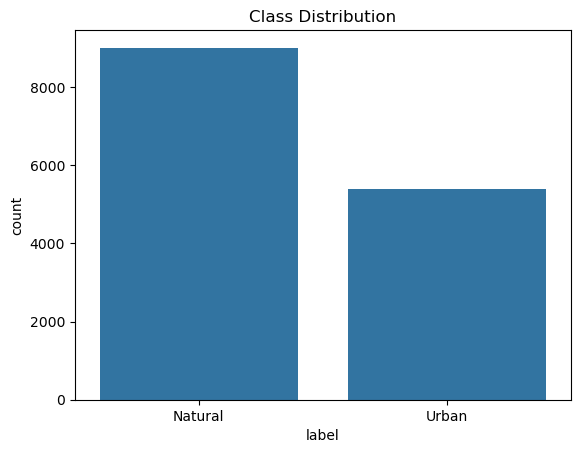

In [3]:

sns.countplot(x=df['label'])
plt.xticks([0, 1], ['Natural', 'Urban'])
plt.title('Class Distribution')
plt.show()


## 3. Image Preprocessing

In [4]:

def preprocess_image(img_path):
    img = cv2.imread(img_path)
    if img is None:
        raise ValueError(f"Failed to load image: {img_path}")
    img = cv2.resize(img, IMAGE_SIZE)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    gray = clahe.apply(gray)

    gray = cv2.GaussianBlur(gray, (5,5), 0)
    return gray


## Train-Test Split (80–20 Stratified)

In [5]:

X_train_paths, X_test_paths, y_train, y_test = train_test_split(
    df["image_path"],
    df["label"],
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)


## 4. Feature Extraction

In [6]:
# 4.1 Intensity Histogram
def intensity_histogram(img, bins=32):
    hist = cv2.calcHist([img], [0], None, [bins], [0,256])
    return cv2.normalize(hist, hist).flatten()

# 4.2 LBP Texture Features
def lbp_features(img, P=8, R=1):
    lbp = local_binary_pattern(img, P, R, method='uniform')
    hist, _ = np.histogram(lbp.ravel(), bins=np.arange(0, P+3), density=True)
    return hist

# 4.3 Edge Features (Canny)
def edge_features(img):
    edges = cv2.Canny(img, 100, 200)
    return [edges.mean(), edges.std()]

# 4.4 HOG Features
def hog_features(img):
    return hog(img, orientations=9, pixels_per_cell=(8,8),
               cells_per_block=(2,2), block_norm='L2-Hys')

# Feature Vector Assembly
def extract_features(img_path):
    img = preprocess_image(img_path)
    features = []
    features.extend(intensity_histogram(img))
    features.extend(lbp_features(img))
    features.extend(edge_features(img))
    features.extend(hog_features(img))
    return np.array(features)

X_train = np.array([extract_features(p) for p in X_train_paths])
X_test  = np.array([extract_features(p) for p in X_test_paths])


## 5. Feature Scaling & PCA

In [7]:

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

pca = PCA(n_components=0.95, random_state=42)
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)

print("Final feature dimension:", X_train.shape[1])


Final feature dimension: 1845


## 6. Model Training with 5-Fold CV

In [8]:

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 6.1 Support Vector Machine
svm = SVC(kernel='rbf', C=10, gamma='scale')
svm_cv = cross_val_score(svm, X_train, y_train, cv=cv, scoring='f1')
print("SVM CV F1:", svm_cv.mean())
svm.fit(X_train, y_train)

# 6.2 Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf_cv = cross_val_score(rf, X_train, y_train, cv=cv, scoring='f1')
print("RF CV F1:", rf_cv.mean())
rf.fit(X_train, y_train)

best_model = svm if svm_cv.mean() > rf_cv.mean() else rf


SVM CV F1: 0.8745865417052823
RF CV F1: 0.6604091279491211


## 7. Model Evaluation

Accuracy: 0.9076388888888889
F1-score: 0.8785388127853881
              precision    recall  f1-score   support

           0       0.93      0.92      0.93      1800
           1       0.87      0.89      0.88      1080

    accuracy                           0.91      2880
   macro avg       0.90      0.90      0.90      2880
weighted avg       0.91      0.91      0.91      2880



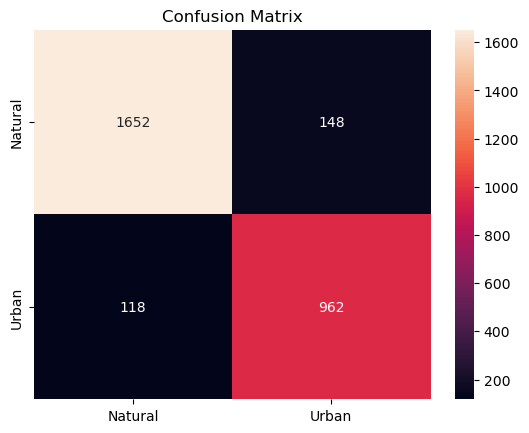

In [9]:

y_pred = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Natural','Urban'],
            yticklabels=['Natural','Urban'])
plt.title("Confusion Matrix")
plt.show()


## 8. Visual Validation on Test Images

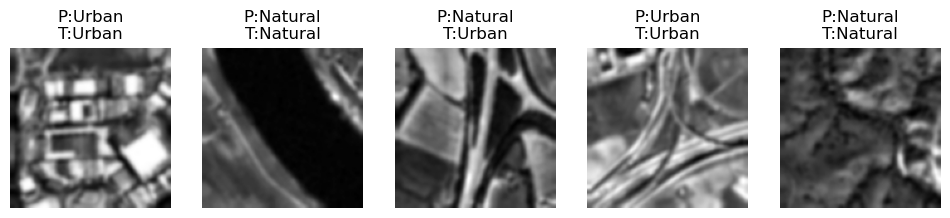

In [10]:

idxs = np.random.choice(len(X_test_paths), 5, replace=False)

plt.figure(figsize=(12,4))
for i, idx in enumerate(idxs):
    img = preprocess_image(X_test_paths.iloc[idx])
    pred = best_model.predict(X_test[idx].reshape(1,-1))[0]
    true = y_test.iloc[idx]

    plt.subplot(1,5,i+1)
    plt.imshow(img, cmap='gray')
    plt.title(f"P:{'Urban' if pred else 'Natural'}\nT:{'Urban' if true else 'Natural'}")
    plt.axis('off')

plt.show()


## 9. External Image Evaluation

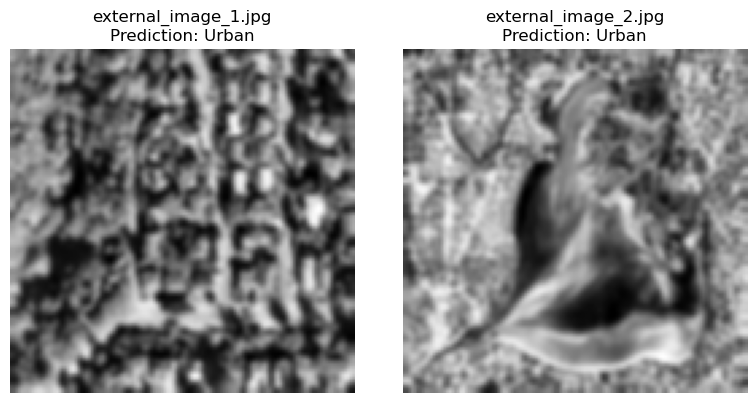

In [11]:

# External Image Evaluation (Two Images)

external_images = [
    "external_image_1.jpg",
    "external_image_2.jpg"
]

plt.figure(figsize=(8,4))

for i, img_path in enumerate(external_images):
    
    # Preprocess for display
    img = preprocess_image(img_path)

    # Feature extraction
    feat = extract_features(img_path)
    feat = scaler.transform(feat.reshape(1, -1))
    feat = pca.transform(feat)

    # Prediction
    pred = best_model.predict(feat)[0]
    pred_label = "Urban" if pred == 1 else "Natural"

    # Display
    plt.subplot(1, 2, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(f"{os.path.basename(img_path)}\nPrediction: {pred_label}")
    plt.axis("off")

plt.tight_layout()
plt.show()





## 10. Analysis & Conclusion

- LBP and HOG provide strong discrimination between structured urban regions and natural textures.
- SVM performs better on high-dimensional handcrafted features.
- Classical pipelines remain effective and interpretable for satellite imagery.

#### Feature Effectiveness and Discriminative Power

The performance of the classification system is largely driven by the complementary nature of the handcrafted features used. Local Binary Patterns (LBP) effectively capture fine-grained texture information, which is particularly useful for distinguishing natural regions such as forests, rivers, and vegetation-dominated areas from man-made surfaces. Natural regions tend to exhibit irregular, stochastic textures, whereas urban regions show more repetitive and structured patterns.

**Histogram of Oriented Gradients (HOG)** contributes significantly by capturing edge orientation and structural layout. Urban areas typically contain strong, directional edges due to buildings, roads, and man-made infrastructure, while natural regions have softer, less regular gradients. The combination of LBP (texture) and HOG (structure) therefore provides a robust mid-level representation for urban–natural discrimination.

Intensity histograms and edge statistics further support this distinction by encoding global brightness distributions and edge density, which are generally higher in built-up regions. The fusion of low-level and mid-level features improves robustness compared to using any single feature type in isolation.


#### Model Performance Trends

Among the evaluated models, Support Vector Machines (SVMs) consistently outperform Random Forests in terms of F1-score. This is expected because SVMs are well-suited for high-dimensional feature spaces produced by HOG and LBP descriptors. The RBF kernel enables non-linear decision boundaries, allowing the model to separate complex feature distributions effectively.

Random Forests perform competitively but show slightly lower generalization performance. This can be attributed to the curse of dimensionality and the tendency of tree-based methods to overfit when faced with a large number of correlated handcrafted features.


#### Error Analysis and Misclassifications

Misclassifications primarily occur in **mixed or transitional land-use regions**, such as suburban areas, agricultural land with built structures, or coastal regions near urban settlements (as seen in the results too). These areas share visual characteristics of both classes, making them challenging for purely handcrafted feature-based systems. Additionally, variations in illumination, seasonal changes, and scale differences in satellite imagery contribute to classification ambiguity.

Another limitation is the lack of explicit spatial context. While HOG captures local structure, the model does not explicitly reason about large-scale spatial relationships, which can be important in satellite imagery.

#### Limitations of the Classical Approach

    * Although the classical vision pipeline is interpretable and computationally efficient, it has inherent limitations:
    * Handcrafted features are sensitive to scale and viewpoint variations.
    * Semantic understanding of complex scenes is limited.
    * Performance may degrade when generalizing to datasets with different resolutions or acquisition conditions.

Despite these limitations, the approach remains valuable for scenarios with limited data, constrained computational resources, or where model interpretability is critical.


## 11. Future Work

Several extensions can further enhance the system:

    1. Hybrid Models: Combine handcrafted features with deep learning–based embeddings (e.g., CNN feature maps) to leverage both interpretability and semantic richness.

    2. Multispectral Information: Incorporate additional spectral bands (e.g., near-infrared) commonly available in satellite imagery to improve discrimination between vegetation and built-up areas.

    3. Spatial Pyramid Representations: Use spatial pyram